In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ---------- FUNCTIONS TO CONVERT RA & DEC ----------

def ra_to_degrees(ra_str):
    # Format: HH:MM:SS
    h, m, s = map(float, ra_str.split(':'))
    return 15 * (h + m/60 + s/3600)   # 1 hour = 15 degrees

def dec_to_degrees(dec_str):
    # Format: ±DD°MM:SS
    dec_str = dec_str.replace('°', ':')
    d, m, s = map(float, dec_str.split(':'))
    sign = -1 if d < 0 else 1
    return sign * (abs(d) + m/60 + s/3600)

In [8]:
# ---------- READ FILE ----------

file_path = "C:/Users/User/Desktop/33446TLE.txt"

# Read while skipping comment lines
df = pd.read_csv(
    file_path,
    comment=';',
    header=None,
    names= ["Date", "Time", "RA", "DEC", "Az", "Alt"],
    encoding="cp1252"   # ← FIX

)

# ---------- CREATE DATETIME COLUMN ----------

df["DateTime"] = df.apply(
    lambda row: datetime.strptime(
        str(row["Date"]) + str(row["Time"]).zfill(6),
        "%Y%m%d%H%M%S"
    ),
    axis=1
)

# ---------- CONVERT RA & DEC ----------

df["RA_deg"] = df["RA"].apply(ra_to_degrees)
df["DEC_deg"] = df["DEC"].apply(dec_to_degrees)



# ---------- READ FILE ----------

file_path = "C:/Users/User/Desktop/33446XML.txt"

# Read while skipping comment lines
dg = pd.read_csv(
    file_path,
    comment=';',
    header=None,
    names= ["Date", "Time", "RA", "DEC", "Az", "Alt"],
    encoding="cp1252"   # ← FIX

)

# ---------- CREATE DATETIME COLUMN ----------

dg["DateTime"] = dg.apply(
    lambda row: datetime.strptime(
        str(row["Date"]) + str(row["Time"]).zfill(6),
        "%Y%m%d%H%M%S"
    ),
    axis=1
)

# ---------- CONVERT RA & DEC ----------

dg["RA_deg"] = dg["RA"].apply(ra_to_degrees)
dg["DEC_deg"] = dg["DEC"].apply(dec_to_degrees)

dRA= df["RA_deg"]-dg["RA_deg"]
dDec= df["DEC_deg"]-dg["DEC_deg"]


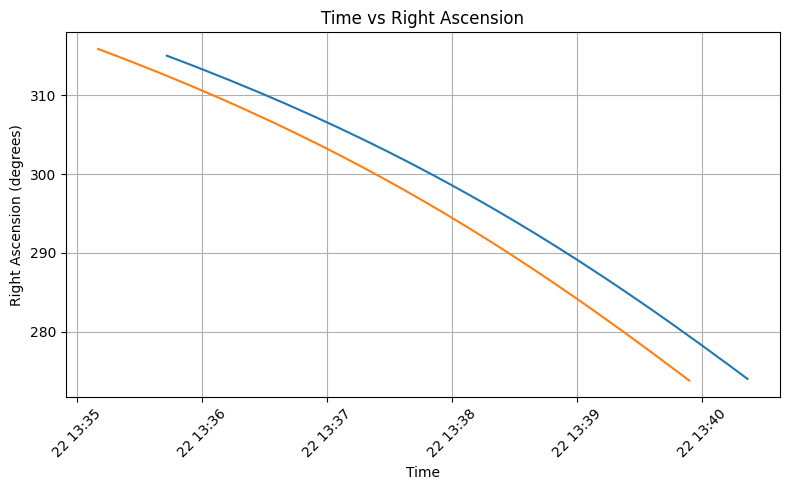

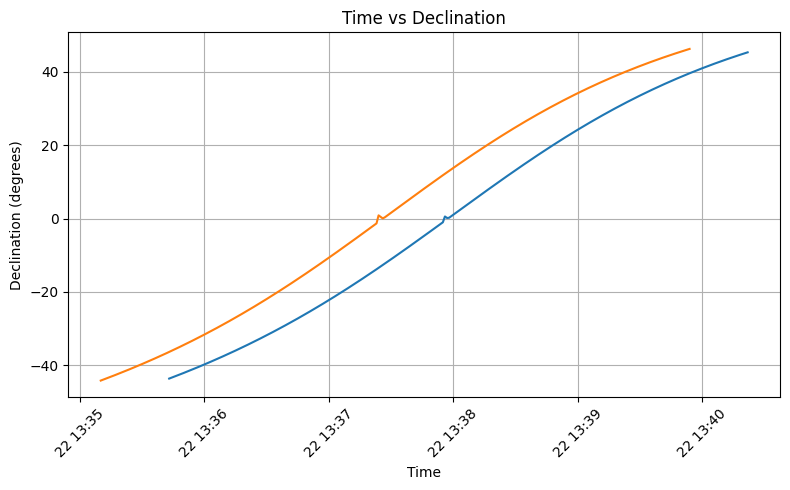

In [9]:

# ---------- PLOT TIME vs RA ----------

plt.figure(figsize=(8,5))
plt.plot(df["DateTime"], df["RA_deg"])
plt.plot(dg["DateTime"], dg["RA_deg"])
plt.xlabel("Time")
plt.ylabel("Right Ascension (degrees)")
plt.title("Time vs Right Ascension")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

# ---------- PLOT TIME vs DEC ----------

plt.figure(figsize=(8,5))
plt.plot(df["DateTime"], df["DEC_deg"])
plt.plot(dg["DateTime"], dg["DEC_deg"])
plt.xlabel("Time")
plt.ylabel("Declination (degrees)")
plt.title("Time vs Declination")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

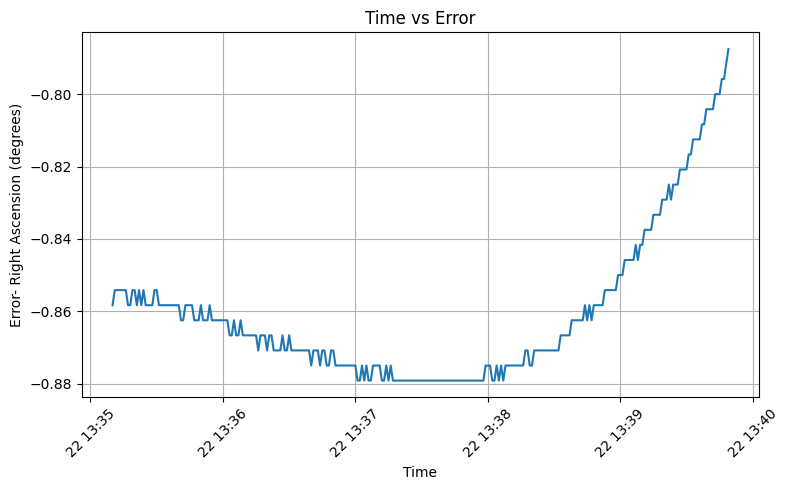

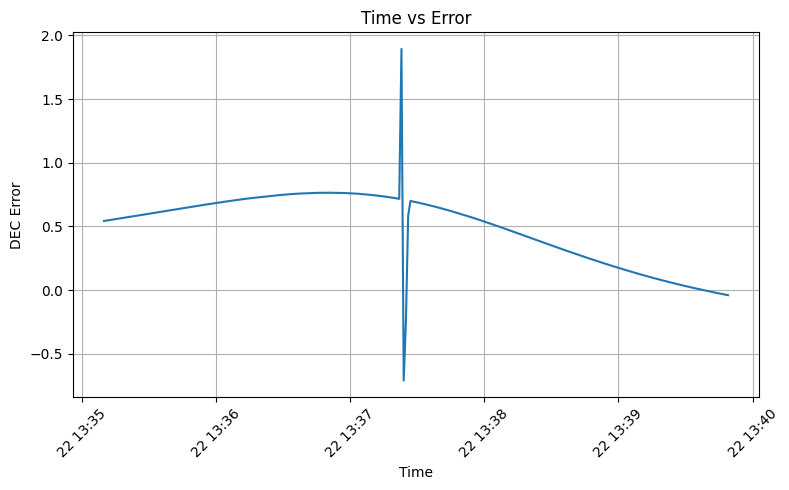

In [10]:
plt.figure(figsize=(8,5))
plt.plot(dg["DateTime"], dRA)

plt.xlabel("Time")
plt.ylabel("Error- Right Ascension (degrees)")
plt.title("Time vs Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(dg["DateTime"], dDec)

plt.xlabel("Time")
plt.ylabel("DEC Error")
plt.title("Time vs Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()